This part import all the necessary libraries

In [1]:
#all the imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

This part checks for null values or zero values things like price , order ID and rating etc can't have zero values

In [2]:
df=pd.read_csv("amazon_sales_2025_INR.csv")
print(df.index)
null=df.isnull()
x = 0

#checking for null values
for i in range(15000):
    for j in range(14):
        a = null.iloc[i,j]
        if a == True :
            print("Null value Detected at",i,j)
            x = 1
            
if x != 1:
    print("\nNo null values present\n")
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1
    
# checkzero function to check if there are zero values in a column
def chkzro (column):
    s = 0
    for i in range (15000):
        a = df.iloc[i,column]
        if a == 0 :
            print("0 value detected at",i,"in column",column)
        else:
            s = 1
    if s == 1 :
        print("No zero value detected in column",column)
        
chkzro(0)
chkzro(1)
chkzro(2)
chkzro(5)
chkzro(6)
chkzro(7)
chkzro(10)


RangeIndex(start=0, stop=15000, step=1)

No null values present

All columns are
0 Order_ID
1 Date
2 Customer_ID
3 Product_Category
4 Product_Name
5 Quantity
6 Unit_Price_INR
7 Total_Sales_INR
8 Payment_Method
9 Delivery_Status
10 Review_Rating
11 Review_Text
12 State
13 Country
No zero value detected in column 0
No zero value detected in column 1
No zero value detected in column 2
No zero value detected in column 5
No zero value detected in column 6
No zero value detected in column 7
No zero value detected in column 10


This part prints the values in pie chart format for better visulization

In [3]:
# starting the analysis
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    return result
    
a = duplicates("Product_Category")
b = duplicates("Product_Name")
c = duplicates("Payment_Method")
d = duplicates("Delivery_Status")
e = duplicates("Review_Rating")
f = duplicates("Review_Text")
g = duplicates("State")

print('Different product categories and their count\n')
print(a,'\n')

print('\nDifferent product name and their count\n')
print(b,'\n')
      
print('\nDifferent Payment Method and their count\n')
print(c,'\n')
      
print('\nDifferent Delivery status of every order and their count\n')
print(d,'\n')
      
print('\nDifferent Rating of all products and their achieved rating count\n')
print(e,'\n')
      
print('\nDifferent review text of orders and their count\n')
print(f,'\n')

print('\nDifferent state where item is and their count\n')
print(g,'\n')


Different product categories and their count

  Product_Category  Count
0      Electronics   3036
1            Books   3035
2         Clothing   3022
3           Beauty   2997
4   Home & Kitchen   2910 


Different product name and their count

        Product_Name  Count
0    Children's Book    636
1            Perfume    629
2   Science Textbook    624
3            T-Shirt    623
4             Laptop    618
5             Tablet    616
6         Smartwatch    615
7          Air Fryer    614
8         Headphones    610
9              Jeans    604
10            Jacket    601
11        Hair Dryer    599
12     Fiction Novel    599
13             Saree    598
14            Comics    597
15          Sneakers    596
16        Face Cream    596
17          Lipstick    590
18           Shampoo    583
19     Mixer Grinder    582
20         Biography    579
21        Smartphone    577
22      Cookware Set    577
23    Water Purifier    570
24    Vacuum Cleaner    567 


Different Payment Method

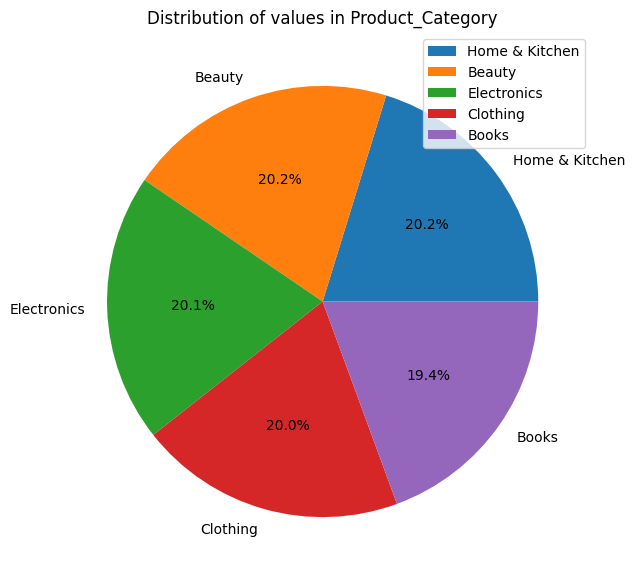

As we can see that household items and daily use items are bought more suggesting that people buy household items more
Also beauty and electronics items are bought more , this suggests that these items are bought in bulk when price goes down




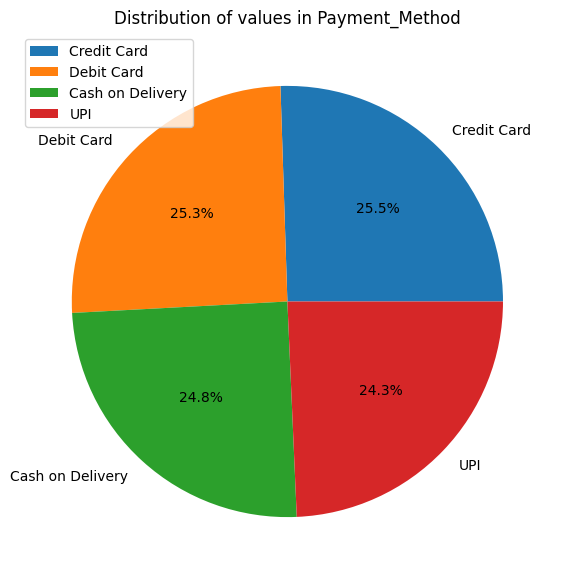

We can see that the payment methods are mostly online with cash on delivery used by only 24.8%
24.3% people have used credit card suggesting people interest in buy now pay later




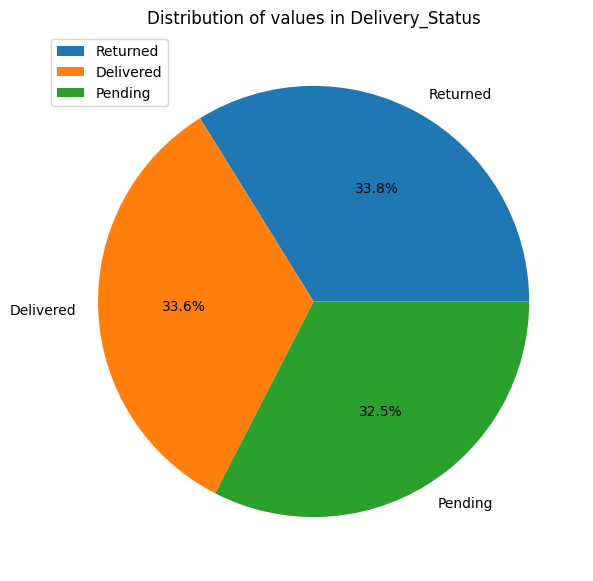

 Out of all products only 33.6% is kept by the customer which means that customer try multiple items and return most items
32.5% orders are still pending due to overload ,it is expected that out of them only one third items will be kept by the customer and rest 
will be returned




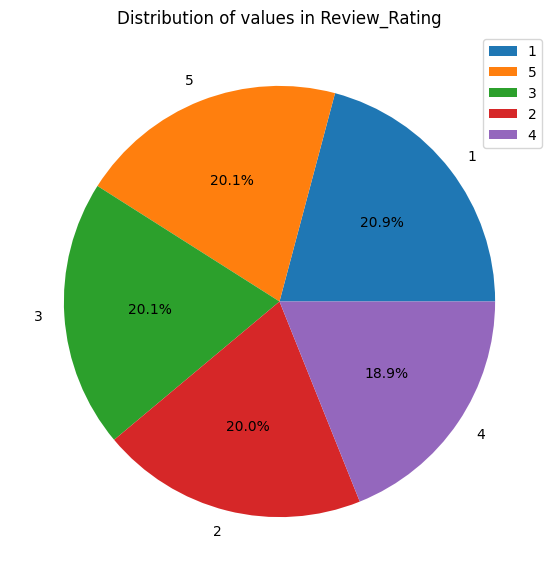

 Only 40% of products have rating of 4 or higher which means that 60% of items are not as good as advertised 
20% of products have 1 star rating suggesting seller is hiding or not giving true information about the products


In [4]:
# Function for printing pie chart 
def piechart(x,y):
    x.plot.pie(y='Count', labels=df[y].unique(), autopct='%1.1f%%', figsize=(7, 7))
    plt.title('Distribution of values in '+y)
    plt.ylabel('')
    plt.show()
    
piechart(a,'Product_Category')
print('''As we can see that household items and daily use items are bought more suggesting that people buy household items more
Also beauty and electronics items are bought more , this suggests that these items are bought in bulk when price goes down''')
print('\n')

piechart(c,'Payment_Method')
print('''We can see that the payment methods are mostly online with cash on delivery used by only 24.8%
24.3% people have used credit card suggesting people interest in buy now pay later''')
print('\n')

piechart(d,'Delivery_Status')
print(''' Out of all products only 33.6% is kept by the customer which means that customer try multiple items and return most items
32.5% orders are still pending due to overload ,it is expected that out of them only one third items will be kept by the customer and rest 
will be returned''')
print('\n')

piechart(e,'Review_Rating')
print(''' Only 40% of products have rating of 4 or higher which means that 60% of items are not as good as advertised 
20% of products have 1 star rating suggesting seller is hiding or not giving true information about the products''')


This part print the total numbers of things like sales , product etc of the data sheet

In [5]:
# Functions for adding all values in a column
def total(q):
    a = df[q].sum()
    return a
at = total("Quantity")
st = total("Total_Sales_INR")

print('\nTotal number of product sold were',at)
print('\nTotal sales done were',st,'₹','> 100 crores')
print('\nTotal number of product sold were',at)
print('\nTotal number of product sold were',at)
print('\nTotal number of product sold were',at)



Total number of product sold were 44770

Total sales done were 1118161803.5 ₹ > 100 crores

Total number of product sold were 44770

Total number of product sold were 44770

Total number of product sold were 44770


This part prints the relation between values

In [6]:
# Function for adding and comparing certain values
def comp(s):
    a = 0
    l = []
    f = 0
    for i in range (15000):
        if df.iloc[i,3] == s:
            a = a + df.iloc[i,5]
            l.append(df.iloc[i,4])
            f += df.iloc[i,7]
    f = int(f)
    lq = pd.Series(l)
    lw = lq.value_counts()
    le = lw.reset_index()
    le.columns = ['Items', 'Count']
    return [a,le,f]

ac = comp('Electronics')
acl = ac[1]
print('Different items in electronics category and their count\n')
print(acl)
print('\nTotal number of electronics items sold were',ac[0],'costing total',ac[2])

bc = comp('Books')
bcl = bc[1]
print('\n\n\nDifferent items in books category and their count\n')
print(bcl)
print('\nTotal number of Books sold were',bc[0],'costing total',bc[2])

cc = comp('Clothing')
ccl = cc[1]
print('\n\n\nDifferent items in clothing category and their count\n')
print(ccl)
print('\nTotal number of Clothing item sold were',cc[0],'costing total',cc[2])

dc = comp('Beauty')
dcl = dc[1]
print('\n\n\nDifferent items in beauty category and their count\n')
print(dcl)
print('\nTotal number of Beauty items sold were',dc[0],'costing total',dc[2])

ec = comp('Home & Kitchen')
ecl = ec[1]
print('\n\n\nDifferent items in home&kitchen category and their count\n')
print(ecl)
print('\nTotal number of Home & Kitchen items sold were',ec[0],'costing total',ec[2])


Different items in electronics category and their count

        Items  Count
0      Laptop    618
1      Tablet    616
2  Smartwatch    615
3  Headphones    610
4  Smartphone    577

Total number of electronics items sold were 9072 costing total 226564923



Different items in books category and their count

              Items  Count
0   Children's Book    636
1  Science Textbook    624
2     Fiction Novel    599
3            Comics    597
4         Biography    579

Total number of Books sold were 8950 costing total 224999226



Different items in clothing category and their count

      Items  Count
0   T-Shirt    623
1     Jeans    604
2    Jacket    601
3     Saree    598
4  Sneakers    596

Total number of Clothing item sold were 8924 costing total 222409335



Different items in beauty category and their count

        Items  Count
0     Perfume    629
1  Hair Dryer    599
2  Face Cream    596
3    Lipstick    590
4     Shampoo    583

Total number of Beauty items sold were 909

This part prints the bar graph of the data

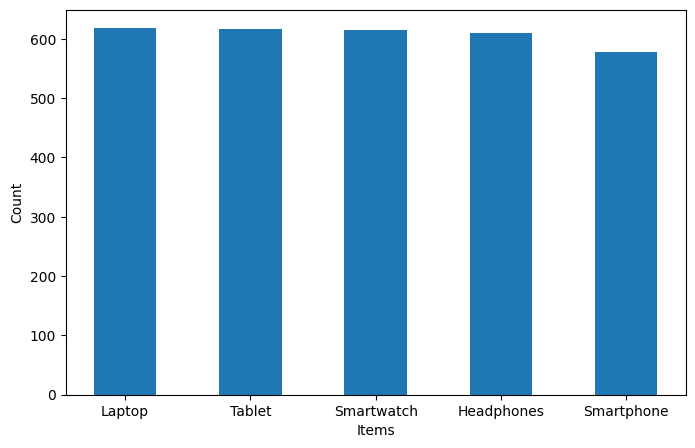

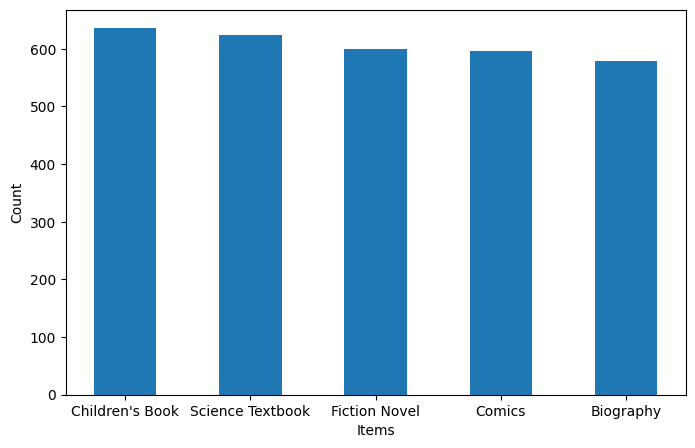

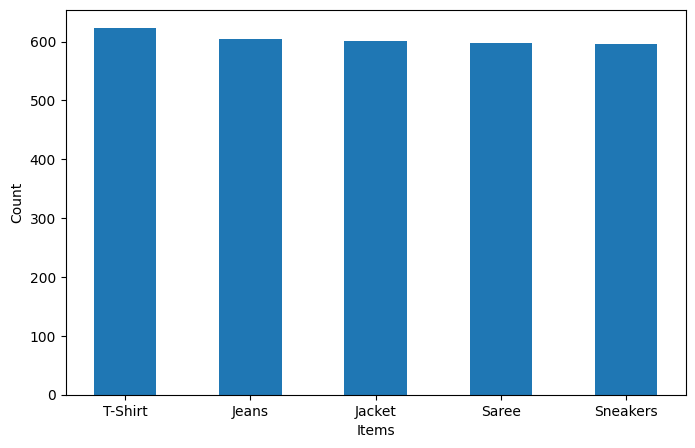

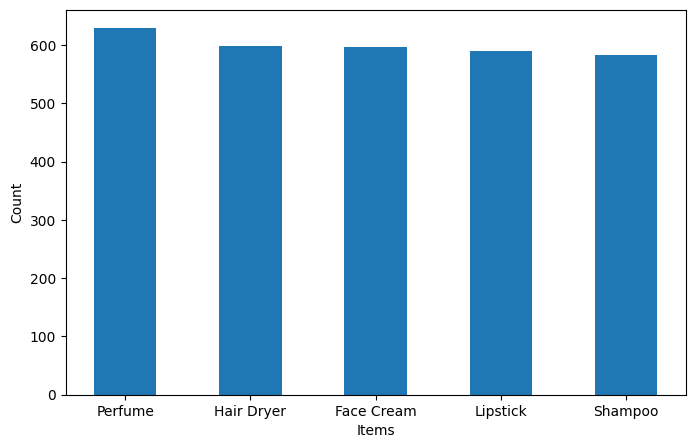

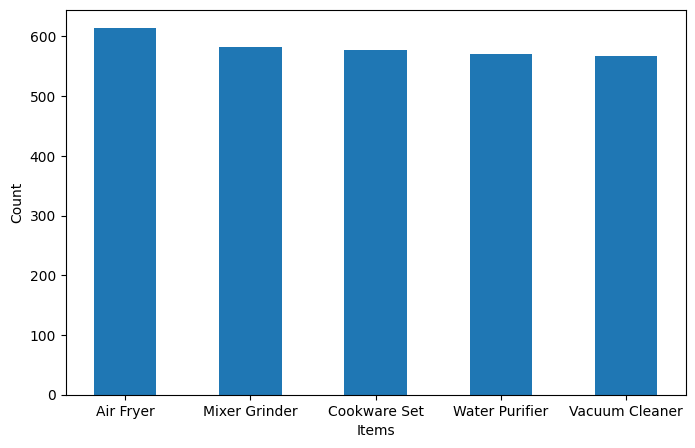

In [27]:
# Function that will plot the bar graph
def plot(l):
    ax = l['Items']
    ay = l['Count']
    plt.figure(figsize=(8, 5))
    plt.bar(ax,ay,width=0.5)
    plt.xlabel('Items')
    plt.ylabel('Count')
    plt.show()

plot(acl)
plot(bcl)
plot(ccl)
plot(dcl)
plot(ecl)


This part prints the Heatmap

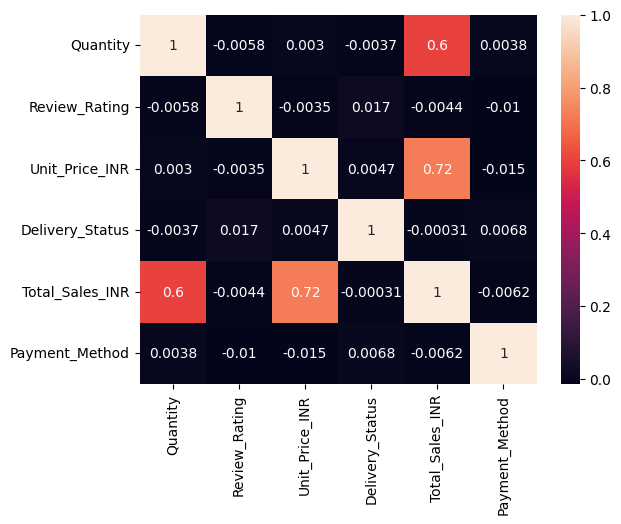

In [38]:
# Relation Analysis
dfc = df.copy()

dfc['Delivery_Status'] = dfc['Delivery_Status'].map({'Delivered':1,'Returned':2,'Pending':3})

dfc['Payment_Method'] = dfc['Payment_Method'].map({'Cash on Delivery':1,'Credit Card':2,'Debit Card':3,'UPI':4})

sns.heatmap(dfc[['Quantity','Review_Rating','Unit_Price_INR','Delivery_Status','Total_Sales_INR','Payment_Method']].corr(),annot=True)

plt.show()
